# 14 - Mapper Exploration and Results

This notebook consolidates the Mapper track into one report-style pass.

It keeps the high-value pieces:

- a concrete Mapper graph example;
- control-aware graph statistics;
- a warning about dimensionality-reduction quality versus graph
  complexity;
- node-level interpretation with metadata-shuffle nulls;
- dataset and raw-patch guardrails;
- a skeptical synthesis of what Mapper is currently telling us.

## Current Readout

Mapper is useful here as a controlled diagnostic, not as evidence for a
literal latent-space topology. At the current exploratory scale, graph
loopiness is mostly not stronger than controls. That is a valuable
negative result.

The positive lead is more modest: Mapper nodes can isolate local regimes
with label, image, spatial, norm, or density structure. Those nodes are
worth inspecting only if they survive metadata nulls and stability
checks.

In [1]:
from __future__ import annotations

from pathlib import Path
import os
import sys
import time
import warnings

for candidate in [Path.cwd(), Path.cwd().parent]:
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.max_open_warning"] = 120
sns.set_theme(style="whitegrid", context="notebook")

from notebook_utils.encoder_explorer import (
    DEFAULT_IMAGE_DIR,
    load_project_images,
    run_raw_patches,
    sample_indices,
    seed_everything,
)
from notebook_utils.mapper_explorer import (
    build_mapper_graph,
    discover_cached_flux_clouds,
    load_cached_flux_cloud,
    load_token_cloud_cache,
    make_control_clouds,
    make_lens_catalog,
    make_projection_catalog,
    mapper_stats,
    node_metadata_summary,
    plot_lens_scatter,
    plot_mapper_diagnostics,
    plot_node_patches,
    projection_quality_table,
    stability_summary,
    subsample_cloud,
)

## 1. Setup

The notebook is cache-first. On this machine it uses the existing ignored
FLUX token caches under `outputs/`; if those are missing, only the parts
that depend on them need to be rerun after encoding/caching tokens.

In [2]:
def parse_int_list(text: str) -> list[int]:
    return [int(part.strip()) for part in text.split(",") if part.strip()]


def parse_str_list(text: str) -> list[str]:
    return [part.strip() for part in text.split(",") if part.strip()]


ROOT = Path.cwd()
if not (ROOT / "notebooks").exists() and (ROOT.parent / "notebooks").exists():
    ROOT = ROOT.parent

SEED = int(os.environ.get("TOKENIZER_NOTEBOOK_SEED", "72"))
SMOKE = os.environ.get("TOKENIZER_SMOKE", "0") == "1"
MAX_POINTS = int(os.environ.get("MAPPER_MAX_POINTS", "900" if SMOKE else "2500"))
SEEDS = parse_int_list(os.environ.get("MAPPER_SEEDS", "72,73" if SMOKE else "72,73,74"))
LENSES = parse_str_list(os.environ.get("MAPPER_LENSES", "pca2_unit,norm_density,pca8_sphere_pca2"))
CONTROLS = parse_str_list(os.environ.get("MAPPER_CONTROLS", "channel_shuffle,matched_gaussian,uniform_sphere,norm_random_directions"))
IMAGE_DIR = os.environ.get("TOKENIZER_IMAGE_DIR", str(DEFAULT_IMAGE_DIR))
IMAGE_SIZE = int(os.environ.get("TOKENIZER_AUTOENCODER_SIZE", "256"))

seed_everything(SEED)

if SMOKE:
    CONFIGS = [
        {"config": "baseline", "n_intervals": 6, "overlap": 0.35, "min_bin_points": 8, "min_cluster_size": 4},
        {"config": "cover_only", "n_intervals": 6, "overlap": 0.35, "min_bin_points": 8, "min_cluster_size": 4, "clusterer": "single"},
    ]
else:
    CONFIGS = [
        {"config": "coarse", "n_intervals": 6, "overlap": 0.30, "min_bin_points": 12, "min_cluster_size": 5},
        {"config": "baseline", "n_intervals": 8, "overlap": 0.35, "min_bin_points": 14, "min_cluster_size": 5},
        {"config": "cover_only", "n_intervals": 8, "overlap": 0.35, "min_bin_points": 14, "min_cluster_size": 5, "clusterer": "single"},
    ]

display(
    pd.DataFrame(
        [
            {"knob": "smoke", "value": SMOKE},
            {"knob": "seed", "value": SEED},
            {"knob": "max_points", "value": MAX_POINTS},
            {"knob": "seeds", "value": SEEDS},
            {"knob": "lenses", "value": LENSES},
            {"knob": "controls", "value": CONTROLS},
        ]
    )
)
display(pd.DataFrame(CONFIGS))

,knob,value
0,smoke,True
1,seed,72
2,max_points,900
3,seeds,"[72, 73]"
4,lenses,"[pca2_unit, norm_density, pca8_sphere_pca2]"
5,controls,"[channel_shuffle, matched_gaussian, uniform_sp..."


,config,n_intervals,overlap,min_bin_points,min_cluster_size,clusterer
0,baseline,6,0.35,8,4,NaN
1,cover_only,6,0.35,8,4,single


## 2. Representative Mapper Graph

The left plot is the lens scatter: individual latent tokens projected by
`pca2_unit`. The middle plot is the Mapper graph: nodes are local
high-dimensional clusters inside overlapping lens bins, and edges mean
nodes share original tokens through cover overlap.

loaded and built representative graph in 0.23s


,nodes,edges,components,graph_h1_rank,coverage_fraction,mean_memberships_per_covered_point,mean_node_size,median_node_size,mean_degree,max_degree,largest_component_fraction,weighted_label_purity,n_input_points,n_lens_dimensions,n_intervals,overlap,min_bin_points,clusterer,min_cluster_size,eps_quantile
0,46,126,3,83,0.76,1.817,27.022,19.5,5.478,11,0.957,0.488,900,2,6,0.35,8,dbscan,4,0.35


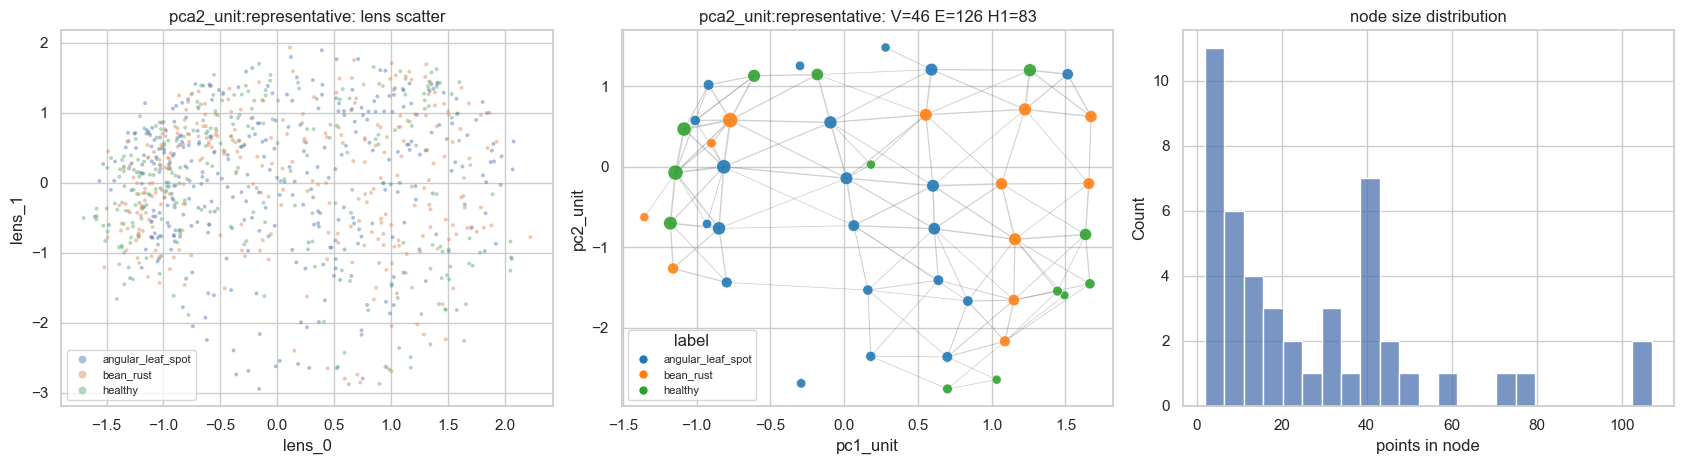

In [3]:
t0 = time.perf_counter()
flux_cloud = load_cached_flux_cloud()
if flux_cloud is None:
    raise FileNotFoundError("Expected cached FLUX cloud under outputs/cycle_hunt/beans_param_sweep")

images = None
try:
    n_images = int(flux_cloud.token_metadata["image_id"].max()) + 1
    images, image_metadata = load_project_images(n_images, IMAGE_DIR)
except Exception as exc:
    print(f"Patch images unavailable: {type(exc).__name__}: {exc}")

x, metadata, source_indices = subsample_cloud(flux_cloud, max_points=MAX_POINTS, seed=SEED)
lenses = make_lens_catalog(x, seed=SEED)
representative_lens = lenses["pca2_unit"]
representative_graph = build_mapper_graph(
    x,
    representative_lens,
    name="pca2_unit:representative",
    source_indices=source_indices,
    n_intervals=CONFIGS[0]["n_intervals"],
    overlap=CONFIGS[0]["overlap"],
    min_bin_points=CONFIGS[0]["min_bin_points"],
    min_cluster_size=CONFIGS[0]["min_cluster_size"],
)

print(f"loaded and built representative graph in {time.perf_counter() - t0:.2f}s")
display(pd.DataFrame([mapper_stats(representative_graph, metadata)]).round(3))
plot_mapper_diagnostics(representative_graph, metadata, label_col="label", max_points=MAX_POINTS, seed=SEED)

## 3. Control-Aware Graph Statistics

This is the main skeptical test. For each seed/lens/config, compare the
observed graph to the strongest control. Positive deltas are leads.
Negative deltas are a warning not to overinterpret graph complexity.

control sweep seconds: 2.52


,lens,config,runs,graph_h1_rank_delta_mean,graph_h1_rank_delta_std,coverage_fraction_delta_mean,nodes_delta_mean
5,pca8_sphere_pca2,cover_only,2,0.0,0.0,0.000,0.0
3,pca2_unit,cover_only,2,-6.5,1.5,-0.001,-2.0
1,norm_density,cover_only,2,-14.5,2.5,-0.006,-5.0
0,norm_density,baseline,2,-63.5,18.5,-0.045,-42.5
4,pca8_sphere_pca2,baseline,2,-105.5,28.5,-0.116,-43.5
2,pca2_unit,baseline,2,-155.0,12.0,-0.126,-47.0


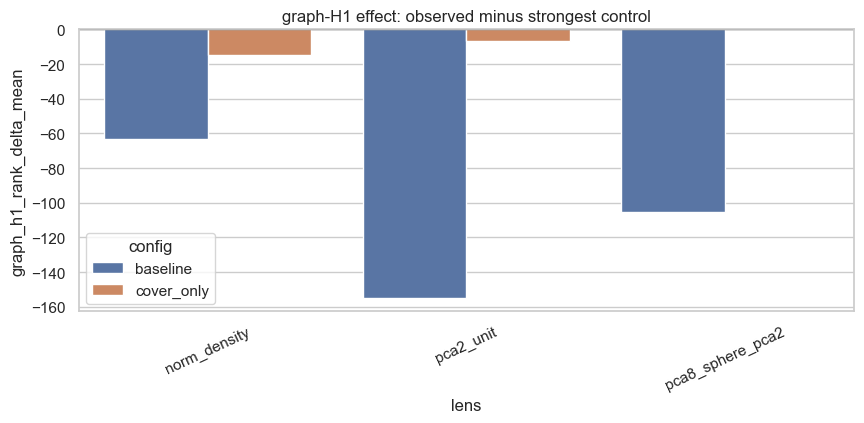

In [4]:
rows = []
t0 = time.perf_counter()
for seed in SEEDS:
    seed_x, seed_metadata, seed_source_indices = subsample_cloud(flux_cloud, max_points=MAX_POINTS, seed=seed)
    sample_clouds = {"observed": seed_x}
    sample_clouds.update({k: v for k, v in make_control_clouds(seed_x, seed=seed).items() if k in CONTROLS})

    for sample_name, sample_x in sample_clouds.items():
        lens_catalog = make_lens_catalog(sample_x, seed=seed)
        for lens_name in LENSES:
            if lens_name not in lens_catalog:
                continue
            for config in CONFIGS:
                graph = build_mapper_graph(
                    sample_x,
                    lens_catalog[lens_name],
                    name=f"{sample_name}:{lens_name}:{config['config']}:seed{seed}",
                    source_indices=seed_source_indices if sample_name == "observed" else None,
                    n_intervals=int(config["n_intervals"]),
                    overlap=float(config["overlap"]),
                    min_bin_points=int(config["min_bin_points"]),
                    clusterer=str(config.get("clusterer", "dbscan")),
                    min_cluster_size=int(config["min_cluster_size"]),
                    eps_quantile=float(config.get("eps_quantile", 0.35)),
                )
                row = {"seed": seed, "sample": sample_name, "lens": lens_name, "config": config["config"]}
                row.update(mapper_stats(graph, seed_metadata if sample_name == "observed" else None))
                rows.append(row)

mapper_runs = pd.DataFrame(rows)
metric_cols = ["nodes", "edges", "components", "graph_h1_rank", "coverage_fraction", "mean_degree"]
observed = mapper_runs[mapper_runs["sample"] == "observed"][["seed", "lens", "config", *metric_cols]]
controls = mapper_runs[mapper_runs["sample"] != "observed"].groupby(["seed", "lens", "config"])[metric_cols].max().reset_index()
effects = observed.merge(controls, on=["seed", "lens", "config"], suffixes=("_observed", "_control_max"))
for metric in metric_cols:
    effects[f"{metric}_delta"] = effects[f"{metric}_observed"] - effects[f"{metric}_control_max"]

effect_summary = stability_summary(effects, ["lens", "config"], [f"{metric}_delta" for metric in metric_cols])
print(f"control sweep seconds: {time.perf_counter() - t0:.2f}")
display(
    effect_summary[
        [
            "lens",
            "config",
            "runs",
            "graph_h1_rank_delta_mean",
            "graph_h1_rank_delta_std",
            "coverage_fraction_delta_mean",
            "nodes_delta_mean",
        ]
    ]
    .sort_values("graph_h1_rank_delta_mean", ascending=False)
    .round(3)
)

fig, ax = plt.subplots(figsize=(8.8, 4.4))
sns.barplot(data=effect_summary, x="lens", y="graph_h1_rank_delta_mean", hue="config", ax=ax)
ax.axhline(0, color="0.35", linewidth=1)
ax.set_title("graph-H1 effect: observed minus strongest control")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 4. Dimensionality Reduction Sanity Check

Mapper starts with a low-dimensional lens, but Mapper graph complexity is
not the same thing as projection quality. This section keeps that
distinction visible.

,projection,trustworthiness,knn_jaccard,pairwise_distance_spearman,label_silhouette_2d,nodes,graph_h1_rank,coverage_fraction
0,spectral_unit,0.862,0.101,0.707,-0.027,27,35,0.724
1,pca_raw,0.860,0.087,0.863,-0.022,35,56,0.726
2,pca_unit,0.854,0.086,0.784,-0.021,46,83,0.760
3,isomap_unit,0.854,0.086,0.746,-0.021,38,62,0.750
4,gaussian_random_projection,0.622,0.023,0.208,-0.016,56,114,0.746


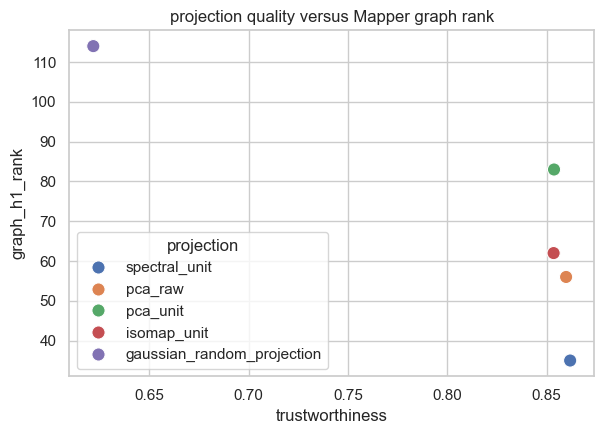

In [5]:
projections, projection_failures = make_projection_catalog(
    x,
    seed=SEED,
    include_slow=False,
    n_neighbors=12 if SMOKE else 16,
)
if not projection_failures.empty:
    display(projection_failures)

quality = projection_quality_table(x, projections, metadata, n_neighbors=12 if SMOKE else 16, seed=SEED)
projection_mapper_rows = []
for projection_name, values in projections.items():
    graph = build_mapper_graph(
        x,
        values,
        name=f"{projection_name}:mapper_lens",
        source_indices=source_indices,
        n_intervals=CONFIGS[0]["n_intervals"],
        overlap=CONFIGS[0]["overlap"],
        min_bin_points=CONFIGS[0]["min_bin_points"],
        min_cluster_size=CONFIGS[0]["min_cluster_size"],
    )
    row = {"projection": projection_name}
    row.update(mapper_stats(graph, metadata))
    projection_mapper_rows.append(row)

projection_mapper = pd.DataFrame(projection_mapper_rows)
joint_projection = quality.merge(
    projection_mapper[["projection", "nodes", "graph_h1_rank", "coverage_fraction"]],
    on="projection",
    how="left",
)
display(joint_projection.sort_values("trustworthiness", ascending=False).round(3))

fig, ax = plt.subplots(figsize=(6.2, 4.5))
sns.scatterplot(data=joint_projection, x="trustworthiness", y="graph_h1_rank", hue="projection", s=90, ax=ax)
ax.set_title("projection quality versus Mapper graph rank")
plt.tight_layout()
plt.show()

## 5. Node Interpretation Example

Graph-level effects are weak so far, but nodes can still be useful as
candidates for local regimes. The null below keeps graph memberships
fixed and permutes metadata, so high purity from tiny nodes does not fool
us too easily.

,node_id,size,degree,token_norm_mean,dominant_label,label_purity,label_purity_excess,dominant_image_fraction,image_concentration_excess,spatial_radius
45,40,4,3,9.298,healthy,1.000,0.440,0.750,0.490,11.182
34,50,12,3,10.708,angular_leaf_spot,0.750,0.270,0.333,0.183,8.955
25,45,17,4,10.931,angular_leaf_spot,0.706,0.242,0.235,0.106,7.040
40,42,5,3,9.253,angular_leaf_spot,0.800,0.232,0.200,-0.040,11.340
18,38,16,5,9.146,healthy,0.688,0.215,0.250,0.130,8.241
35,13,10,3,6.422,angular_leaf_spot,0.700,0.188,0.200,0.036,10.469
50,46,4,1,10.717,angular_leaf_spot,0.750,0.170,0.250,-0.040,3.836
19,18,13,5,5.880,bean_rust,0.615,0.160,0.154,0.022,12.294
47,54,4,2,13.162,healthy,0.750,0.160,0.750,0.500,7.920
42,12,4,3,7.013,angular_leaf_spot,0.750,0.150,0.750,0.470,9.816


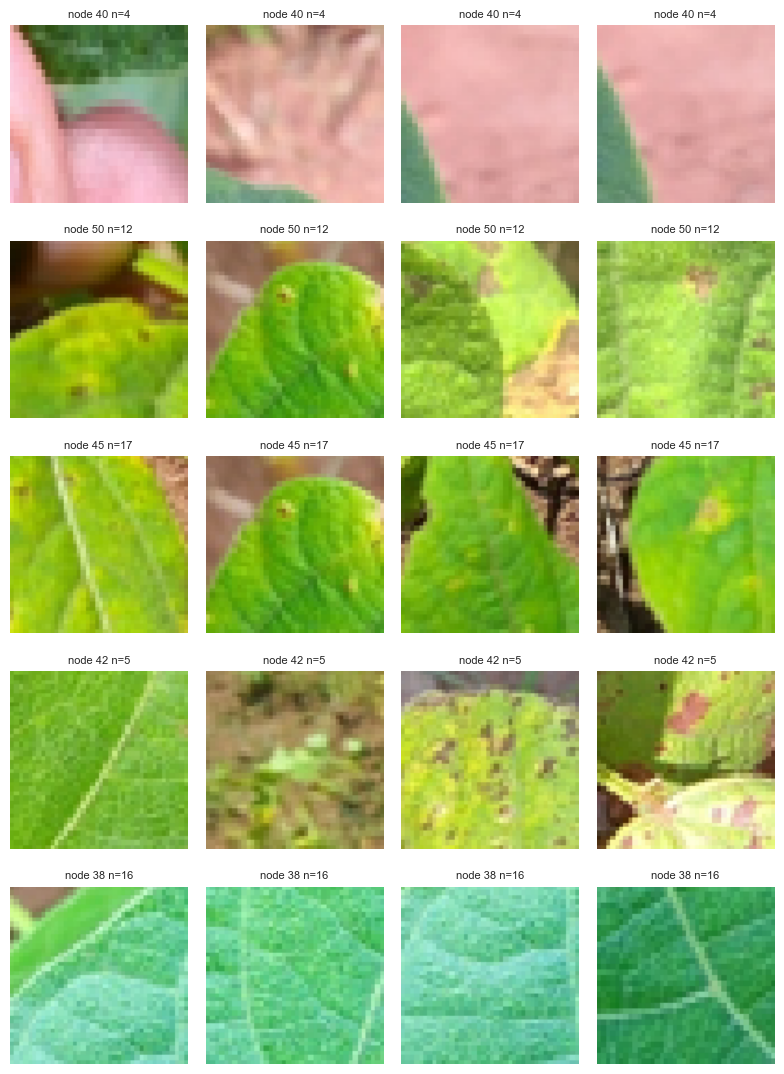

In [6]:
interpret_lens = lenses["norm_density"]
interpret_graph = build_mapper_graph(
    x,
    interpret_lens,
    name="norm_density:interpretation",
    source_indices=source_indices,
    n_intervals=CONFIGS[0]["n_intervals"],
    overlap=CONFIGS[0]["overlap"],
    min_bin_points=CONFIGS[0]["min_bin_points"],
    min_cluster_size=CONFIGS[0]["min_cluster_size"],
)
node_summary = node_metadata_summary(interpret_graph, x, metadata, label_col="label")

rng = np.random.default_rng(SEED)
labels = metadata["label"].astype(str).to_numpy()
image_ids = metadata["image_id"].astype(str).to_numpy()
node_points = {
    int(node_id): group["point_index"].to_numpy(dtype=int)
    for node_id, group in interpret_graph.memberships.groupby("node_id")
}
null_rows = []
n_perm = 25 if SMOKE else 100
for node_id, point_idx in node_points.items():
    label_scores = []
    image_scores = []
    for _ in range(n_perm):
        perm_labels = rng.permutation(labels)
        perm_images = rng.permutation(image_ids)
        label_scores.append(pd.Series(perm_labels[point_idx]).value_counts(normalize=True).iloc[0])
        image_scores.append(pd.Series(perm_images[point_idx]).value_counts(normalize=True).iloc[0])
    null_rows.append(
        {
            "node_id": node_id,
            "label_purity_null_mean": float(np.mean(label_scores)),
            "dominant_image_fraction_null_mean": float(np.mean(image_scores)),
        }
    )
null_summary = pd.DataFrame(null_rows)
node_summary = node_summary.merge(null_summary, on="node_id", how="left")
node_summary["label_purity_excess"] = node_summary["label_purity"] - node_summary["label_purity_null_mean"]
node_summary["image_concentration_excess"] = node_summary["dominant_image_fraction"] - node_summary["dominant_image_fraction_null_mean"]

display(
    node_summary[
        [
            "node_id",
            "size",
            "degree",
            "token_norm_mean",
            "dominant_label",
            "label_purity",
            "label_purity_excess",
            "dominant_image_fraction",
            "image_concentration_excess",
            "spatial_radius",
        ]
    ]
    .sort_values(["label_purity_excess", "size"], ascending=False)
    .head(12)
    .round(3)
)

if images is not None:
    candidate_nodes = (
        node_summary.sort_values(["label_purity_excess", "size"], ascending=False)["node_id"]
        .head(5)
        .astype(int)
        .tolist()
    )
    plot_node_patches(interpret_graph, flux_cloud, images, node_ids=candidate_nodes, patches_per_node=4, max_nodes=5, image_size=IMAGE_SIZE)

## 6. Dataset and Raw-Patch Guardrails

Two sanity checks prevent an overly FLUX-specific story:

- compare cached FLUX clouds across image domains;
- compare FLUX tokens to raw centered image patches on Beans.

In [7]:
dataset_rows = []
cache_table = discover_cached_flux_clouds()
requested = {"beans_local", "cifar10", "fashion_mnist"}
for _, cache_row in cache_table[cache_table["dataset"].isin(requested)].iterrows():
    dataset = cache_row["dataset"]
    cloud = load_token_cloud_cache(cache_row["cloud_path"], cache_row["metadata_path"], name=dataset)
    dataset_x, dataset_metadata, dataset_source_indices = subsample_cloud(cloud, max_points=MAX_POINTS, seed=SEED)
    sample_clouds = {"observed": dataset_x}
    sample_clouds.update({k: v for k, v in make_control_clouds(dataset_x, seed=SEED).items() if k in CONTROLS})
    for sample_name, sample_x in sample_clouds.items():
        lens_catalog = make_lens_catalog(sample_x, seed=SEED)
        for lens_name in ["pca2_unit", "norm_density"]:
            graph = build_mapper_graph(
                sample_x,
                lens_catalog[lens_name],
                name=f"{dataset}:{sample_name}:{lens_name}",
                source_indices=dataset_source_indices if sample_name == "observed" else None,
                n_intervals=CONFIGS[0]["n_intervals"],
                overlap=CONFIGS[0]["overlap"],
                min_bin_points=CONFIGS[0]["min_bin_points"],
                min_cluster_size=CONFIGS[0]["min_cluster_size"],
            )
            row = {"dataset": dataset, "sample": sample_name, "lens": lens_name}
            row.update(mapper_stats(graph, dataset_metadata if sample_name == "observed" else None))
            dataset_rows.append(row)

dataset_runs = pd.DataFrame(dataset_rows)
ds_metric_cols = ["nodes", "graph_h1_rank", "coverage_fraction"]
ds_obs = dataset_runs[dataset_runs["sample"] == "observed"][["dataset", "lens", *ds_metric_cols]]
ds_ctrl = dataset_runs[dataset_runs["sample"] != "observed"].groupby(["dataset", "lens"])[ds_metric_cols].max().reset_index()
dataset_effects = ds_obs.merge(ds_ctrl, on=["dataset", "lens"], suffixes=("_observed", "_control_max"))
for metric in ds_metric_cols:
    dataset_effects[f"{metric}_delta"] = dataset_effects[f"{metric}_observed"] - dataset_effects[f"{metric}_control_max"]

rep_rows = []
if images is not None:
    keep = flux_cloud.token_metadata["image_id"].to_numpy(dtype=int) < len(images)
    flux_tokens = flux_cloud.tokens[keep].astype(np.float32)
    flux_meta = flux_cloud.token_metadata.loc[keep].reset_index(drop=True)
    raw_cloud = run_raw_patches(images, image_metadata, image_size=IMAGE_SIZE)
    reps = {
        "flux_vae": (flux_tokens, flux_meta),
        "raw_patches": (raw_cloud.tokens.astype(np.float32), raw_cloud.token_metadata.reset_index(drop=True)),
    }
    for rep_name, (tokens, rep_meta) in reps.items():
        idx = sample_indices(len(tokens), min(MAX_POINTS, len(tokens)), seed=SEED)
        rep_x = tokens[idx]
        rep_metadata = rep_meta.iloc[idx].reset_index(drop=True)
        sample_clouds = {"observed": rep_x}
        sample_clouds.update({k: v for k, v in make_control_clouds(rep_x, seed=SEED).items() if k in {"channel_shuffle", "uniform_sphere", "norm_random_directions"}})
        for sample_name, sample_x in sample_clouds.items():
            lens_catalog = make_lens_catalog(sample_x, seed=SEED)
            for lens_name in ["pca2_unit", "norm_density"]:
                graph = build_mapper_graph(
                    sample_x,
                    lens_catalog[lens_name],
                    name=f"{rep_name}:{sample_name}:{lens_name}",
                    source_indices=idx if sample_name == "observed" else None,
                    n_intervals=CONFIGS[0]["n_intervals"],
                    overlap=CONFIGS[0]["overlap"],
                    min_bin_points=CONFIGS[0]["min_bin_points"],
                    min_cluster_size=CONFIGS[0]["min_cluster_size"],
                )
                row = {"representation": rep_name, "sample": sample_name, "lens": lens_name}
                row.update(mapper_stats(graph, rep_metadata if sample_name == "observed" else None))
                rep_rows.append(row)

rep_runs = pd.DataFrame(rep_rows)
rep_effects = pd.DataFrame()
if not rep_runs.empty:
    rep_obs = rep_runs[rep_runs["sample"] == "observed"][["representation", "lens", *ds_metric_cols]]
    rep_ctrl = rep_runs[rep_runs["sample"] != "observed"].groupby(["representation", "lens"])[ds_metric_cols].max().reset_index()
    rep_effects = rep_obs.merge(rep_ctrl, on=["representation", "lens"], suffixes=("_observed", "_control_max"))
    for metric in ds_metric_cols:
        rep_effects[f"{metric}_delta"] = rep_effects[f"{metric}_observed"] - rep_effects[f"{metric}_control_max"]

print("Dataset effects")
display(dataset_effects[["dataset", "lens", "graph_h1_rank_delta", "coverage_fraction_delta", "nodes_delta"]].round(3))
if not rep_effects.empty:
    print("Representation effects")
    display(rep_effects[["representation", "lens", "graph_h1_rank_delta", "coverage_fraction_delta", "nodes_delta"]].round(3))

Dataset effects


,dataset,lens,graph_h1_rank_delta,coverage_fraction_delta,nodes_delta
0,beans_local,pca2_unit,-167,-0.118,-52
1,beans_local,norm_density,-82,-0.048,-43
2,cifar10,pca2_unit,-204,-0.204,-36
3,cifar10,norm_density,-101,-0.089,-14
4,fashion_mnist,pca2_unit,-243,-0.316,-42
5,fashion_mnist,norm_density,-130,-0.230,-46


Representation effects


,representation,lens,graph_h1_rank_delta,coverage_fraction_delta,nodes_delta
0,flux_vae,pca2_unit,-167,-0.118,-52
1,flux_vae,norm_density,-82,-0.048,-43
2,raw_patches,pca2_unit,-145,-0.249,-53
3,raw_patches,norm_density,-124,-0.176,-39


## 7. Synthesis and Saved Tables

Current conclusion: Mapper is giving us useful negative evidence at the
graph-statistic level and useful leads at the node-interpretation level.
The next confirmatory target should not be graph-H1 rank. It should be
stable, interpretable node regimes matched across seeds and checked
against dependence-preserving controls.

In [8]:
out_dir = ROOT / "outputs" / "mapper"
out_dir.mkdir(parents=True, exist_ok=True)
mapper_runs.to_csv(out_dir / "consolidated_mapper_runs.csv", index=False)
effects.to_csv(out_dir / "consolidated_mapper_effects.csv", index=False)
effect_summary.to_csv(out_dir / "consolidated_mapper_effect_summary.csv", index=False)
node_summary.to_csv(out_dir / "consolidated_node_summary.csv", index=False)
dataset_effects.to_csv(out_dir / "consolidated_dataset_effects.csv", index=False)
if not rep_effects.empty:
    rep_effects.to_csv(out_dir / "consolidated_representation_effects.csv", index=False)

notes = []
best_effect = effect_summary.sort_values("graph_h1_rank_delta_mean", ascending=False).head(1)
if not best_effect.empty:
    r = best_effect.iloc[0]
    notes.append(f"Best graph-H1 effect: {r['lens']} / {r['config']} = {r['graph_h1_rank_delta_mean']:.2f}.")
positive_nodes = int((node_summary["label_purity_excess"] > 0.15).sum())
notes.append(f"Node interpretation lead count: {positive_nodes} nodes with label-purity excess > 0.15 in the representative norm-density graph.")
if "graph_h1_rank_delta" in dataset_effects:
    dataset_positive = int((dataset_effects["graph_h1_rank_delta"] > 0).sum())
    notes.append(f"Dataset guardrail: {dataset_positive} dataset/lens pairs had positive graph-H1 delta in this compact run.")
if not rep_effects.empty:
    rep_positive = int((rep_effects["graph_h1_rank_delta"] > 0).sum())
    notes.append(f"Raw-patch guardrail: {rep_positive} representation/lens pairs had positive graph-H1 delta.")

for i, note in enumerate(notes, start=1):
    print(f"{i}. {note}")
print(f"saved compact tables to {out_dir}")

1. Best graph-H1 effect: pca8_sphere_pca2 / cover_only = 0.00.
2. Node interpretation lead count: 10 nodes with label-purity excess > 0.15 in the representative norm-density graph.
3. Dataset guardrail: 0 dataset/lens pairs had positive graph-H1 delta in this compact run.
4. Raw-patch guardrail: 0 representation/lens pairs had positive graph-H1 delta.
saved compact tables to /Users/vitaly/Code/latent-space-topology/outputs/mapper
